
# Round‑Robin (RR) Scheduler with Communication Path Costs

This notebook implements a Round‑Robin scheduler for a distributed application and platform model, **including**:
- Task dependencies derived from application messages (sender → receiver).
- Communication costs based on **shortest paths** in the platform graph.
- **Penalties** when messages traverse inter‑domain routers (`RTSNx` and `RIDx`) **and** the communicating tasks are on **different levels** (Edge/Fog/C1/C2/C3). Each occurrence adds **+10** to the path cost (penalty applies **only** on `RTSNx` and `RIDx`).  
- Message size is also factored into communication delay.

> Within the same level (E‑E or F‑F or C1‑C1 or C2‑C2 or C3‑C3), no penalty is applied (routers `Rxxx` within a level do not incur penalty).



## How Round‑Robin (RR) scheduling works (brief)
Round‑Robin is a **time‑sharing** policy. Each ready task receives a fixed time quantum `Q` on its assigned processor. If it does not finish within `Q`, it is **preempted** and placed at the end of the ready queue for that processor. This continues until the task completes.

Here, RR runs **per‑processor**, while a **system‑level dispatcher** assigns each task to a specific processing node (based on allowed levels) before execution.


In [1]:

# --- Setup & Parameters ---
import json, math, itertools, collections
from pathlib import Path
import networkx as nx
import matplotlib.pyplot as plt

JSON_PATH = r'C:/Users/oheka/Desktop/FTCodes/ModularFTcodes/Platforms/Omar/Omar/250/Application/TC250.json'
# JSON_PATH =   r'C:/Users/oheka/Desktop/FTCodes/ModularFTcodes/Platforms/TC100_NewPM.json'
# RR parameters
TIME_QUANTUM = 10           # time slice for RR (you can change)
CONTEXT_SWITCH_COST = 0     # optional context switch overhead per preemption

# Communication model parameters
HOP_COST = 1                # cost per hop
MSG_SIZE_FACTOR = 1         # multiply message size to contribute to delay
RID_RTSN_PENALTY = 10       # +10 per occurrence of RID* or RTSN* on path (only if crossing levels)

# Mapping from application 'can_run_on' codes to platform 'levels'
# You can adjust this mapping to match your experiment design.
LEVEL_MAP = {
    1: "C1",   # Cloud level 1
    2: "C2",   # Cloud level 2
    3: "C3",   # Cloud level 3
    4: "E",    # Edge
    5: "F",    # Fog
    6: "C1"    # Fallback to a cloud level (you can change to 'C2'/'C3' or a policy)
}


In [2]:

# --- Load JSON (application + platform) ---
with open(JSON_PATH, "r") as f:
    data = json.load(f)

jobs = data["application"]["jobs"]
messages = data["application"]["messages"]
nodes = data["platform"]["nodes"]
links = data["platform"]["links"]

print(f"Loaded: {len(jobs)} jobs, {len(messages)} messages, {len(nodes)} nodes, {len(links)} links.")


Loaded: 250 jobs, 523 messages, 195 nodes, 574 links.


In [3]:

# --- Build platform graph ---
import networkx as nx

G = nx.Graph()
for n in nodes:
    G.add_node(n["id"], is_router=n["is_router"])

for e in links:
    G.add_edge(e["start"], e["end"])

# Helper: infer 'level' of a node by its prefix
def node_level(nid: str) -> str:
    if nid.startswith("E"):
        return "E"   # Edge
    if nid.startswith("F"):
        return "F"   # Fog
    if nid.startswith("P100") or nid.startswith("R1"):
        return "C1"  # Cloud level 1
    if nid.startswith("P200") or nid.startswith("R2"):
        return "C2"  # Cloud level 2
    if nid.startswith("P300") or nid.startswith("R3"):
        return "C3"  # Cloud level 3
    # Inter-domain / special
    if nid.startswith("RID"):
        return "X"   # Inter-domain backbone
    if nid.startswith("RTSN"):
        return "X"   # Special inter-partition switch
    return "U"       # Unknown

# Partition processing nodes by level (only non-router compute nodes)
level_pools = {"E": [], "F": [], "C1": [], "C2": [], "C3": []}
for n in nodes:
    nid = n["id"]
    if not n["is_router"]:
        lvl = node_level(nid)
        if lvl in level_pools:
            level_pools[lvl].append(nid)

for k in level_pools:
    level_pools[k].sort()

level_pools


{'E': ['E31', 'E32', 'E33', 'E34'],
 'F': ['F101',
  'F102',
  'F103',
  'F104',
  'F105',
  'F106',
  'F107',
  'F108',
  'F109',
  'F110',
  'F111',
  'F112',
  'F113',
  'F114',
  'F115'],
 'C1': ['P1001',
  'P1002',
  'P1003',
  'P1004',
  'P1005',
  'P1006',
  'P1007',
  'P1008',
  'P1009'],
 'C2': ['P2001',
  'P2002',
  'P2003',
  'P2004',
  'P2005',
  'P2006',
  'P2007',
  'P2008',
  'P2009'],
 'C3': ['P3001',
  'P3002',
  'P3003',
  'P3004',
  'P3005',
  'P3006',
  'P3007',
  'P3008',
  'P3009']}

In [4]:
from functools import lru_cache

@lru_cache(maxsize=None)
def shortest_path(u, v):
    try:
        return nx.shortest_path(G, u, v)
    except nx.NetworkXNoPath:
        return None

def comm_cost(u, v, msg_size, src_level, dst_level):
    # Always return (delay, path_list)
    if u == v:
        return (0, [u])

    path = shortest_path(u, v)
    if not path:
        return (float("inf"), [])

    hops = max(0, len(path) - 1)
    base = hops * HOP_COST + msg_size * MSG_SIZE_FACTOR

    penalty = 0
    if src_level != dst_level:
        for nid in path:
            if nid.startswith("RID") or nid.startswith("RTSN"):
                penalty += RID_RTSN_PENALTY

    return (base + penalty, path)


In [5]:

# --- Build dependency graph from messages (sender -> receiver) ---
dep_in = {j["id"]: set() for j in jobs}
dep_out = {j["id"]: set() for j in jobs}

# Some messages might reference task ids that don't exist; guard against that
job_ids = set(dep_in.keys())

for m in messages:
    s = m["sender"]
    r = m["receiver"]
    if s in job_ids and r in job_ids:
        dep_out[s].add(r)
        dep_in[r].add(s)

# Quick stats
n_edges = sum(len(v) for v in dep_out.values())
roots = [j for j in job_ids if len(dep_in[j]) == 0]
print(f"Dependency edges: {n_edges}; roots: {len(roots)}")


Dependency edges: 523; roots: 48


In [6]:

# --- Assign each job to a concrete processing node ---
# Policy: use the 'can_run_on' codes to map to a level via LEVEL_MAP,
# then round-robin pick a node from that level's pool.

from collections import defaultdict, deque

level_rr_index = {lvl: 0 for lvl in level_pools}

job_to_node = {}
job_to_level = {}

def pick_node_for_levels(level_list):
    # Try levels in the given list order; round-robin within a level
    for lv_code in level_list:
        lvl = LEVEL_MAP.get(lv_code, None)
        if lvl in level_pools and level_pools[lvl]:
            i = level_rr_index[lvl] % len(level_pools[lvl])
            node = level_pools[lvl][i]
            level_rr_index[lvl] += 1
            return node, lvl
    return None, None

for j in jobs:
    allowed = j["can_run_on"]
    node, lvl = pick_node_for_levels(allowed)
    if node is None:
        # Fallback: try all levels if allowed mapping is empty or invalid
        for lvl in ["E","F","C1","C2","C3"]:
            if level_pools[lvl]:
                i = level_rr_index[lvl] % len(level_pools[lvl])
                node = level_pools[lvl][i]
                level_rr_index[lvl] += 1
                break
    job_to_node[j["id"]] = node
    job_to_level[j["id"]] = node_level(node) if node else "U"

# Sanity
assigned_levels = collections.Counter(job_to_level.values())
assigned_levels


Counter({'C1': 151, 'C2': 46, 'C3': 34, 'E': 19})

In [7]:

# --- RR Simulation ---
# Model:
#  - Per-processor RR queues.
#  - A task becomes 'ready' when all its predecessors have finished and the incoming
#    message transmissions have completed.
#  - When a task finishes, its outgoing messages incur communication delay before
#    the receivers become ready (if all other deps are done).
#
# Time is simulated using a simple event loop.

from heapq import heappush, heappop
eventq = []
event_seq = 0  # tie-breaker

def push_event(t, etype, payload):
    global event_seq
    event_seq += 1
    heappush(eventq, (t, event_seq, etype, payload))

# Build per-node processor records
processor_nodes = sorted(set(job_to_node.values()))
per_node_queue = {p: collections.deque() for p in processor_nodes}
per_node_busy_until = {p: 0 for p in processor_nodes}
per_node_running = {p: None for p in processor_nodes}

# Remaining compute time per job
job_pt = {j["id"]: j["processing_times"] for j in jobs}

# Track job start/finish times
job_start = {}
job_finish = {}

# Track remaining dependencies; copy of dep_in
remaining_deps = {jid: set(s) for jid, s in dep_in.items()}

# For each edge s->r, we must wait comm_cost after s finished before r can ready (if last dep)
# We'll manage "communication done time" per (s->r)
comm_ready_time = {}   # (s,r) -> absolute time when message has arrived

# Global event queue: (time, typ, payload)
# typ in {"task_done", "quantum_done", "comm_done"}
eventq = []

def enqueue_ready_task(jid, now):
    # Push task into its processor's RR queue
    p = job_to_node[jid]
    per_node_queue[p].append(jid)

def try_activate_roots(now):
    for jid in remaining_deps:
        if len(remaining_deps[jid]) == 0 and jid not in job_start and jid not in job_finish:
            # No deps -> ready at time 0
            enqueue_ready_task(jid, now)

# Initialize
now = 0
try_activate_roots(now)

def dispatch_if_idle(p, now):
    if per_node_running[p] is not None:
        return
    if per_node_queue[p]:
        jid = per_node_queue[p].popleft()
        per_node_running[p] = jid
        if jid not in job_start:
            job_start[jid] = now
        slice_time = min(TIME_QUANTUM, job_pt[jid])
        finish_or_preempt = now + slice_time
        push_event(now + slice_time, "quantum_done", {"p": p, "jid": jid, "slice": slice_time})

# Main loop
unfinished = set(job_pt.keys())

while unfinished or eventq:
    # Dispatch on all processors
    for p in processor_nodes:
        dispatch_if_idle(p, now)

    if not eventq:
        # No scheduled events; if queues are empty but unfinished tasks exist, advance time to next possible comm
        break

    t, _, typ, payload = heappop(eventq)
    now = t

    if typ == "quantum_done":
        p = payload["p"]; jid = payload["jid"]; slice_time = payload["slice"]
        assert per_node_running[p] == jid
        job_pt[jid] -= slice_time

        if job_pt[jid] <= 0:
            # Task finished
            per_node_running[p] = None
            job_finish[jid] = now
            unfinished.discard(jid)

            # Schedule comm delays for outgoing edges
            for r in dep_out[jid]:
                # compute comm delay based on path & penalties
                src_node = job_to_node[jid]
                dst_node = job_to_node[r]
                src_lvl = job_to_level[jid]
                dst_lvl = job_to_level[r]

                delay, path = comm_cost(src_node, dst_node, 
                                        msg_size=next(m["size"] for m in messages if m["sender"]==jid and m["receiver"]==r),
                                        src_level=src_lvl, dst_level=dst_lvl)
                arrive = now + delay
                comm_ready_time[(jid, r)] = arrive
                push_event(arrive, "comm_done", {"s": jid, "r": r})

        else:
            # Preempt and requeue (RR)
            per_node_running[p] = None
            if CONTEXT_SWITCH_COST > 0:
                push_event(now + CONTEXT_SWITCH_COST, "requeue", {"p": p, "jid": jid})
            else:
                push_event(now, "requeue", {"p": p, "jid": jid})


    elif typ == "requeue":
        p = payload["p"]; jid = payload["jid"]
        per_node_queue[p].append(jid)

    elif typ == "comm_done":
        s = payload["s"]; r = payload["r"]
        # Mark dep s->r satisfied (in addition to s finishing)
        if s in remaining_deps[r]:
            remaining_deps[r].remove(s)
        # If this was the last dep AND all incoming comms done -> make r ready
        if len(remaining_deps[r]) == 0:
            # Ensure all (pred,r) comms have arrived
            preds = dep_in[r]
            if all(comm_ready_time.get((u, r), 0) <= now for u in preds):
                enqueue_ready_task(r, now)

# Done; compute makespan
makespan = max(job_finish.values()) if job_finish else 0
print(f"Makespan: {makespan}")


Makespan: 2698


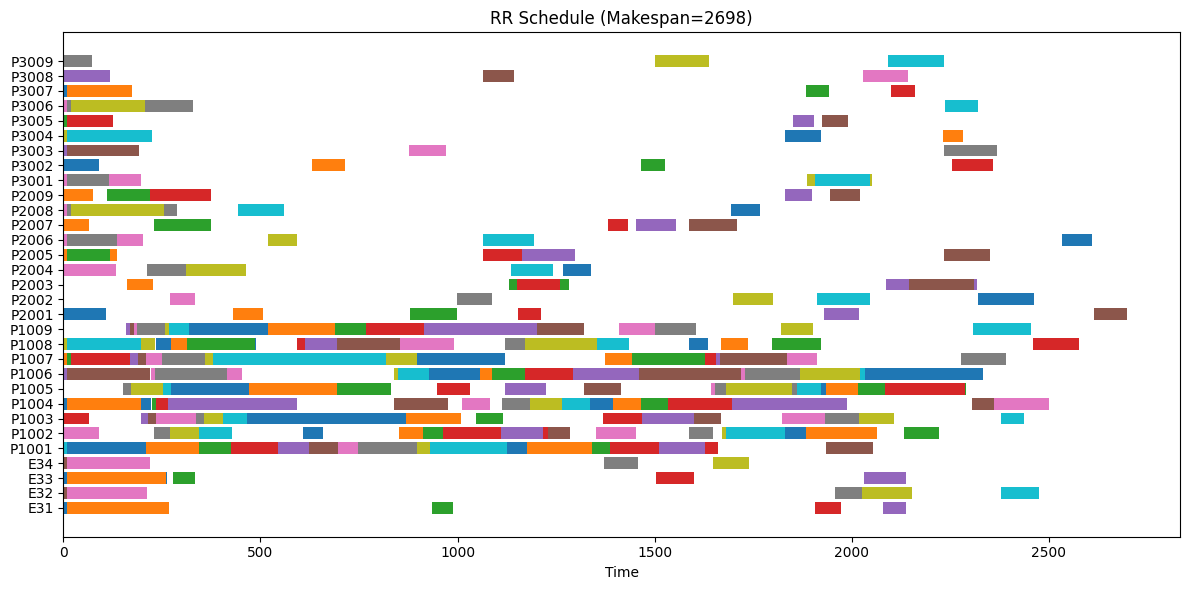

In [8]:

# --- Gantt Chart (rough) ---
import matplotlib.pyplot as plt

# Build per-processor intervals
per_proc_intervals = {p: [] for p in sorted(processor_nodes)}

# We didn't store slices; reconstruct simple intervals as [start, finish] per job on its processor.
# For visualization, just show one bar per job on its processor.
for jid, start in job_start.items():
    fin = job_finish.get(jid, start)
    p = job_to_node[jid]
    per_proc_intervals[p].append((start, fin, jid))

# Plot
plt.figure(figsize=(12, 6))
yticks = []
yticklabels = []
y = 0
for p in sorted(per_proc_intervals.keys()):
    for (s, f, jid) in sorted(per_proc_intervals[p]):
        plt.barh(y, f - s, left=s)
    yticks.append(y)
    yticklabels.append(p)
    y += 1

plt.yticks(yticks, yticklabels)
plt.xlabel("Time")
plt.title(f"RR Schedule (Makespan={makespan})")
plt.tight_layout()
plt.show()


In [9]:

# --- Summary ---
print("Assigned levels:", dict(collections.Counter(job_to_level.values())))
print("Total tasks:", len(job_start))
print("Finished tasks:", len(job_finish))
print("Makespan:", makespan)


Assigned levels: {'C1': 151, 'C3': 34, 'C2': 46, 'E': 19}
Total tasks: 250
Finished tasks: 250
Makespan: 2698
